# **Transformers na Prática**

**Bibliotecas usadas**

- **torch** → Base para tensores e redes neurais
- **transformers** → Modelos pré-treinados da HuggingFace
- **matplotlib** → Visualizações
- **seaborn** → Heatmaps mais bonitos


## **Mecanismo de Atenção (Dot-Product Attention)**

In [2]:
import torch
import torch.nn.functional as F

def dot_product_attention(Q, K, V):
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (Q.shape[-1] ** 0.5)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

batch, seq_len, d_k = 1, 4, 8
Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

out, attn = dot_product_attention(Q, K, V)
print("Output shape:", out.shape)
print("Attention weights:\n", attn)

Output shape: torch.Size([1, 4, 8])
Attention weights:
 tensor([[[0.1244, 0.1449, 0.0466, 0.6841],
         [0.3381, 0.1687, 0.2521, 0.2411],
         [0.2765, 0.1412, 0.0624, 0.5199],
         [0.0618, 0.0508, 0.8724, 0.0150]]])


## **Positional Encoding + Heatmap**

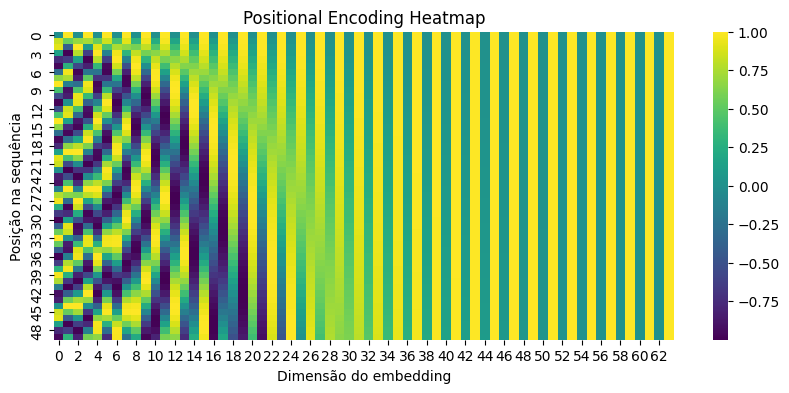

In [5]:
import math
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

seq_len = 50
d_model = 64
pe = positional_encoding(seq_len, d_model)

plt.figure(figsize=(10, 4))
sns.heatmap(pe.numpy(), cmap="viridis")
plt.title("Positional Encoding Heatmap")
plt.xlabel("Dimensão do embedding")
plt.ylabel("Posição na sequência")
plt.show()

## **Carregando GPT-2 com HuggingFace**

In [6]:
from transformers import AutoModel

model = AutoModel.from_pretrained("gpt2")
print(model)

/home/willemromao/miniconda3/envs/curso-llms-agentes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 654.65it/s, Materializing param=wte.weight]             
GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)
